# Exploratory Data Analysis (EDA) - SAND Challenge Task 1 Dataset

**Group Members:**
- **Saneha Akhtar** - Dataset Overview & File Distribution Analysis
- **Sohaib Mubashir** - Audio Properties & Duration Analysis  
- **Azka Hafeez** - Frequency Analysis (Spectrograms, Mel Spectrograms, MFCCs)

This notebook performs comprehensive EDA on the audio dataset containing phonation and rhythm recordings.

## 1. Import Required Libraries

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from scipy import stats
from scipy.io import wavfile
from matplotlib.backends.backend_pdf import PdfPages
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Create plots directory if it doesn't exist
plots_dir = 'plots'
os.makedirs(plots_dir, exist_ok=True)

# Initialize PDF for saving all plots
pdf_path = os.path.join(plots_dir, 'eda_analysis.pdf')
pdf_pages = PdfPages(pdf_path)

---
## PART 1: Dataset Overview & File Distribution Analysis
**Assigned to: Saneha Akhtar**

---

## 2. Dataset Overview

In [29]:
# Define base path
base_path = r'SAND_Challenge_task1_dataset\task1\training'

# Define categories
categories = ['phonationA', 'phonationE', 'phonationI', 'phonationO', 'phonationU',
              'rhythmKA', 'rhythmPA', 'rhythmTA']

# Count files in each category
file_counts = {}
for category in categories:
    category_path = os.path.join(base_path, category)
    if os.path.exists(category_path):
        files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
        file_counts[category] = len(files)
    else:
        file_counts[category] = 0

# Display file counts
print("Dataset Overview:")
print("=" * 50)
for category, count in file_counts.items():
    print(f"{category:15s}: {count:4d} files")
print("=" * 50)
print(f"Total files: {sum(file_counts.values())}")

# Create a summary dataframe
summary_df = pd.DataFrame(list(file_counts.items()), columns=['Category', 'File_Count'])
print("\nSummary DataFrame:")
print(summary_df)

Dataset Overview:
phonationA     :  272 files
phonationE     :  272 files
phonationI     :  272 files
phonationO     :  272 files
phonationU     :  272 files
rhythmKA       :  272 files
rhythmPA       :  272 files
rhythmTA       :  272 files
Total files: 2176

Summary DataFrame:
     Category  File_Count
0  phonationA         272
1  phonationE         272
2  phonationI         272
3  phonationO         272
4  phonationU         272
5    rhythmKA         272
6    rhythmPA         272
7    rhythmTA         272


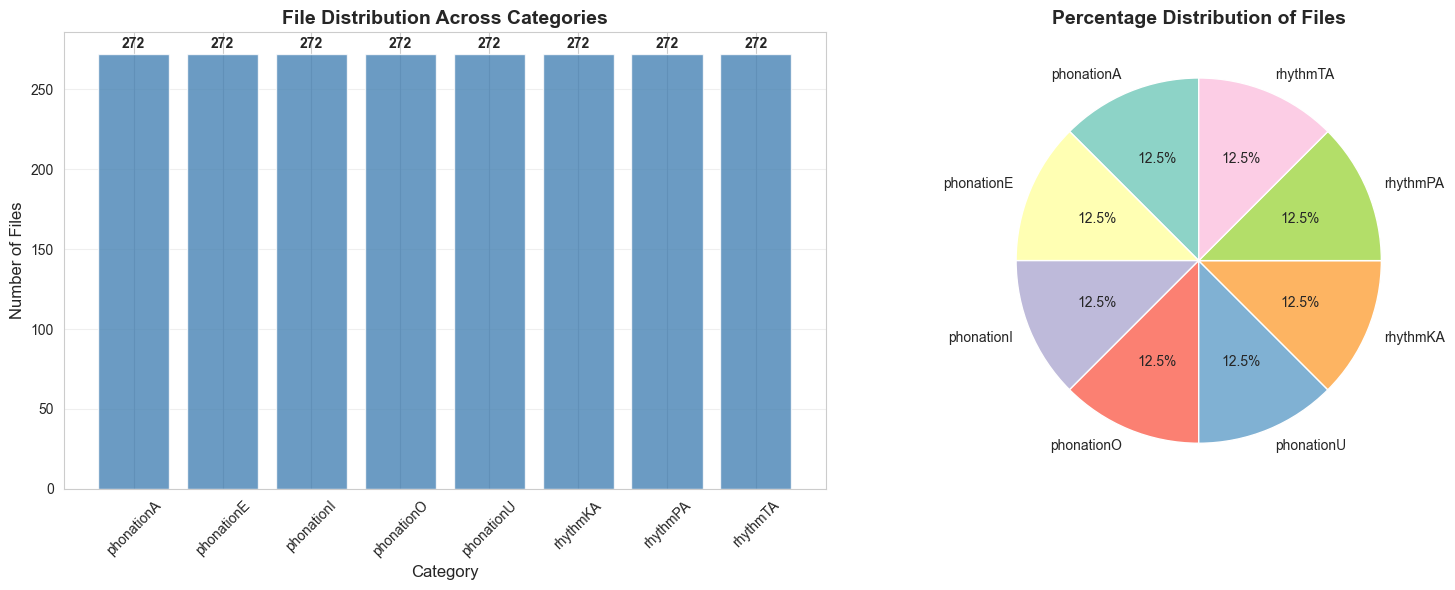

In [30]:
# Visualize file distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
axes[0].bar(summary_df['Category'], summary_df['File_Count'], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Category', fontsize=12)
axes[0].set_ylabel('Number of Files', fontsize=12)
axes[0].set_title('File Distribution Across Categories', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(summary_df['File_Count']):
    axes[0].text(i, v + 2, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
colors = plt.cm.Set3(range(len(categories)))
axes[1].pie(summary_df['File_Count'], labels=summary_df['Category'], autopct='%1.1f%%',
            startangle=90, colors=colors)
axes[1].set_title('Percentage Distribution of Files', fontsize=14, fontweight='bold')

plt.tight_layout()
pdf_pages.savefig(fig, bbox_inches='tight', dpi=300)
plt.show()

---
## PART 2: Audio Properties, Duration and Waveform Analysis
**By Sohaib Mubashir**

---

## 3. Audio File Properties Analysis

In [ ]:
# Function to extract audio properties
def extract_audio_properties(file_path):
    """Extract basic properties from an audio file."""
    try:
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)
        
        # Calculate properties
        duration = librosa.get_duration(y=y, sr=sr)
        samples = len(y)
        
        return {
            'duration': duration,
            'sample_rate': sr,
            'samples': samples
        }
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Sample files from each category (first 10 files)
audio_data = []

for category in categories:
    category_path = os.path.join(base_path, category)
    if os.path.exists(category_path):
        files = [f for f in os.listdir(category_path) if f.endswith('.wav')][:10]  # Sample first 10
        
        for file in files:
            file_path = os.path.join(category_path, file)
            props = extract_audio_properties(file_path)
            
            if props:
                audio_data.append({
                    'Category': category,
                    'File': file,
                    'Duration (s)': props['duration'],
                    'Sample Rate (Hz)': props['sample_rate'],
                    'Samples': props['samples']
                })

# Create dataframe
audio_df = pd.DataFrame(audio_data)
print(f"Analyzed {len(audio_df)} sample files")
print("\nSample Data:")
print(audio_df.head(10))

Analyzed 80 sample files

Sample Data:
     Category                  File  Duration (s)  Sample Rate (Hz)  Samples
0  phonationA  ID000_phonationA.wav          9.88              8000    79040
1  phonationA  ID001_phonationA.wav         17.48              8000   139840
2  phonationA  ID002_phonationA.wav         23.72              8000   189760
3  phonationA  ID003_phonationA.wav         12.00              8000    96000
4  phonationA  ID005_phonationA.wav          6.92              8000    55360
5  phonationA  ID006_phonationA.wav         12.36              8000    98880
6  phonationA  ID007_phonationA.wav         16.44              8000   131520
7  phonationA  ID008_phonationA.wav         36.68              8000   293440
8  phonationA  ID009_phonationA.wav         11.44              8000    91520
9  phonationA  ID010_phonationA.wav         33.40              8000   267200


In [ ]:
# Statistical summary of audio properties
print("Statistical Summary of Audio Properties:")
print("=" * 80)
print("\nDuration Statistics (seconds):")
print(audio_df.groupby('Category')['Duration (s)'].describe())

print("\nSample Rate Statistics (Hz):")
print(audio_df.groupby('Category')['Sample Rate (Hz)'].describe())

# Overall statistics
print("\n" + "=" * 80)
print("Overall Statistics:")
print(f"Average Duration: {audio_df['Duration (s)'].mean():.2f} seconds")
print(f"Min Duration: {audio_df['Duration (s)'].min():.2f} seconds")
print(f"Max Duration: {audio_df['Duration (s)'].max():.2f} seconds")
print(f"Std Duration: {audio_df['Duration (s)'].std():.2f} seconds")
print(f"\nSample Rate(s): {audio_df['Sample Rate (Hz)'].unique()}")

Statistical Summary of Audio Properties:

Duration Statistics (seconds):
            count    mean        std   min    25%    50%    75%    max
Category                                                              
phonationA   10.0  18.032  10.116316  6.92  11.58  14.40  22.16  36.68
phonationE   10.0  17.248  10.052835  5.80   9.87  15.26  19.93  38.64
phonationI   10.0  17.396  10.670390  5.96  10.22  14.40  21.05  41.28
phonationO   10.0  17.952  10.848087  6.80   9.93  14.56  21.12  40.80
phonationU   10.0  17.576  10.700765  5.84  10.68  14.22  20.43  38.28
rhythmKA     10.0  15.108   8.432172  5.40   9.03  12.54  20.90  28.40
rhythmPA     10.0  17.380  11.342745  5.64   9.34  13.08  24.47  38.16
rhythmTA     10.0  17.256  11.700183  6.32  10.58  12.54  19.75  45.04

Sample Rate Statistics (Hz):
            count    mean  std     min     25%     50%     75%     max
Category                                                              
phonationA   10.0  8000.0  0.0  8000.0  8000.

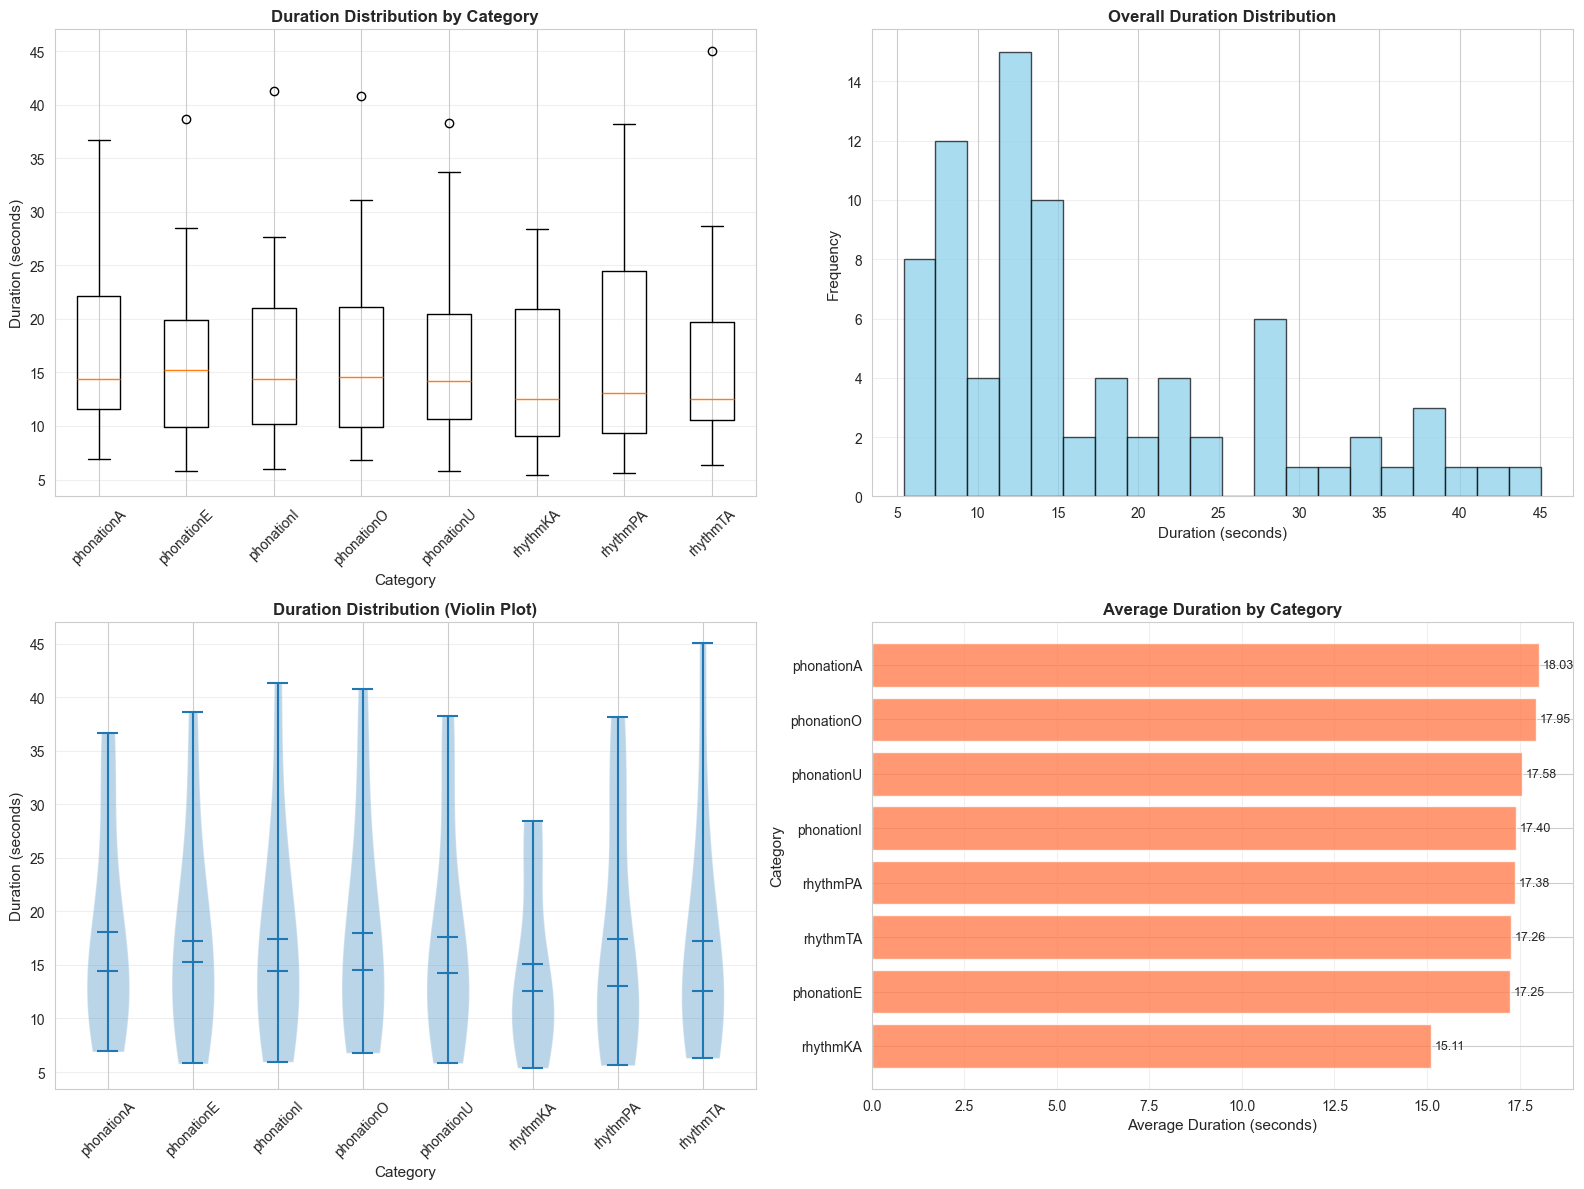

In [ ]:
# Visualize duration distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Box plot - Duration by Category
axes[0, 0].boxplot([audio_df[audio_df['Category'] == cat]['Duration (s)'].values 
                     for cat in categories],
                    labels=categories)
axes[0, 0].set_xlabel('Category', fontsize=11)
axes[0, 0].set_ylabel('Duration (seconds)', fontsize=11)
axes[0, 0].set_title('Duration Distribution by Category', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Histogram - Overall Duration Distribution
axes[0, 1].hist(audio_df['Duration (s)'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Duration (seconds)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Overall Duration Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Violin plot - Duration by Category
category_data = [audio_df[audio_df['Category'] == cat]['Duration (s)'].values for cat in categories]
positions = range(1, len(categories) + 1)
parts = axes[1, 0].violinplot(category_data, positions=positions, showmeans=True, showmedians=True)
axes[1, 0].set_xticks(positions)
axes[1, 0].set_xticklabels(categories, rotation=45)
axes[1, 0].set_xlabel('Category', fontsize=11)
axes[1, 0].set_ylabel('Duration (seconds)', fontsize=11)
axes[1, 0].set_title('Duration Distribution (Violin Plot)', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Bar plot - Average Duration by Category
avg_duration = audio_df.groupby('Category')['Duration (s)'].mean().sort_values()
axes[1, 1].barh(avg_duration.index, avg_duration.values, color='coral', alpha=0.8)
axes[1, 1].set_xlabel('Average Duration (seconds)', fontsize=11)
axes[1, 1].set_ylabel('Category', fontsize=11)
axes[1, 1].set_title('Average Duration by Category', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(avg_duration.values):
    axes[1, 1].text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
pdf_pages.savefig(fig, bbox_inches='tight', dpi=300)
plt.show()

## 4. Waveform Visualization


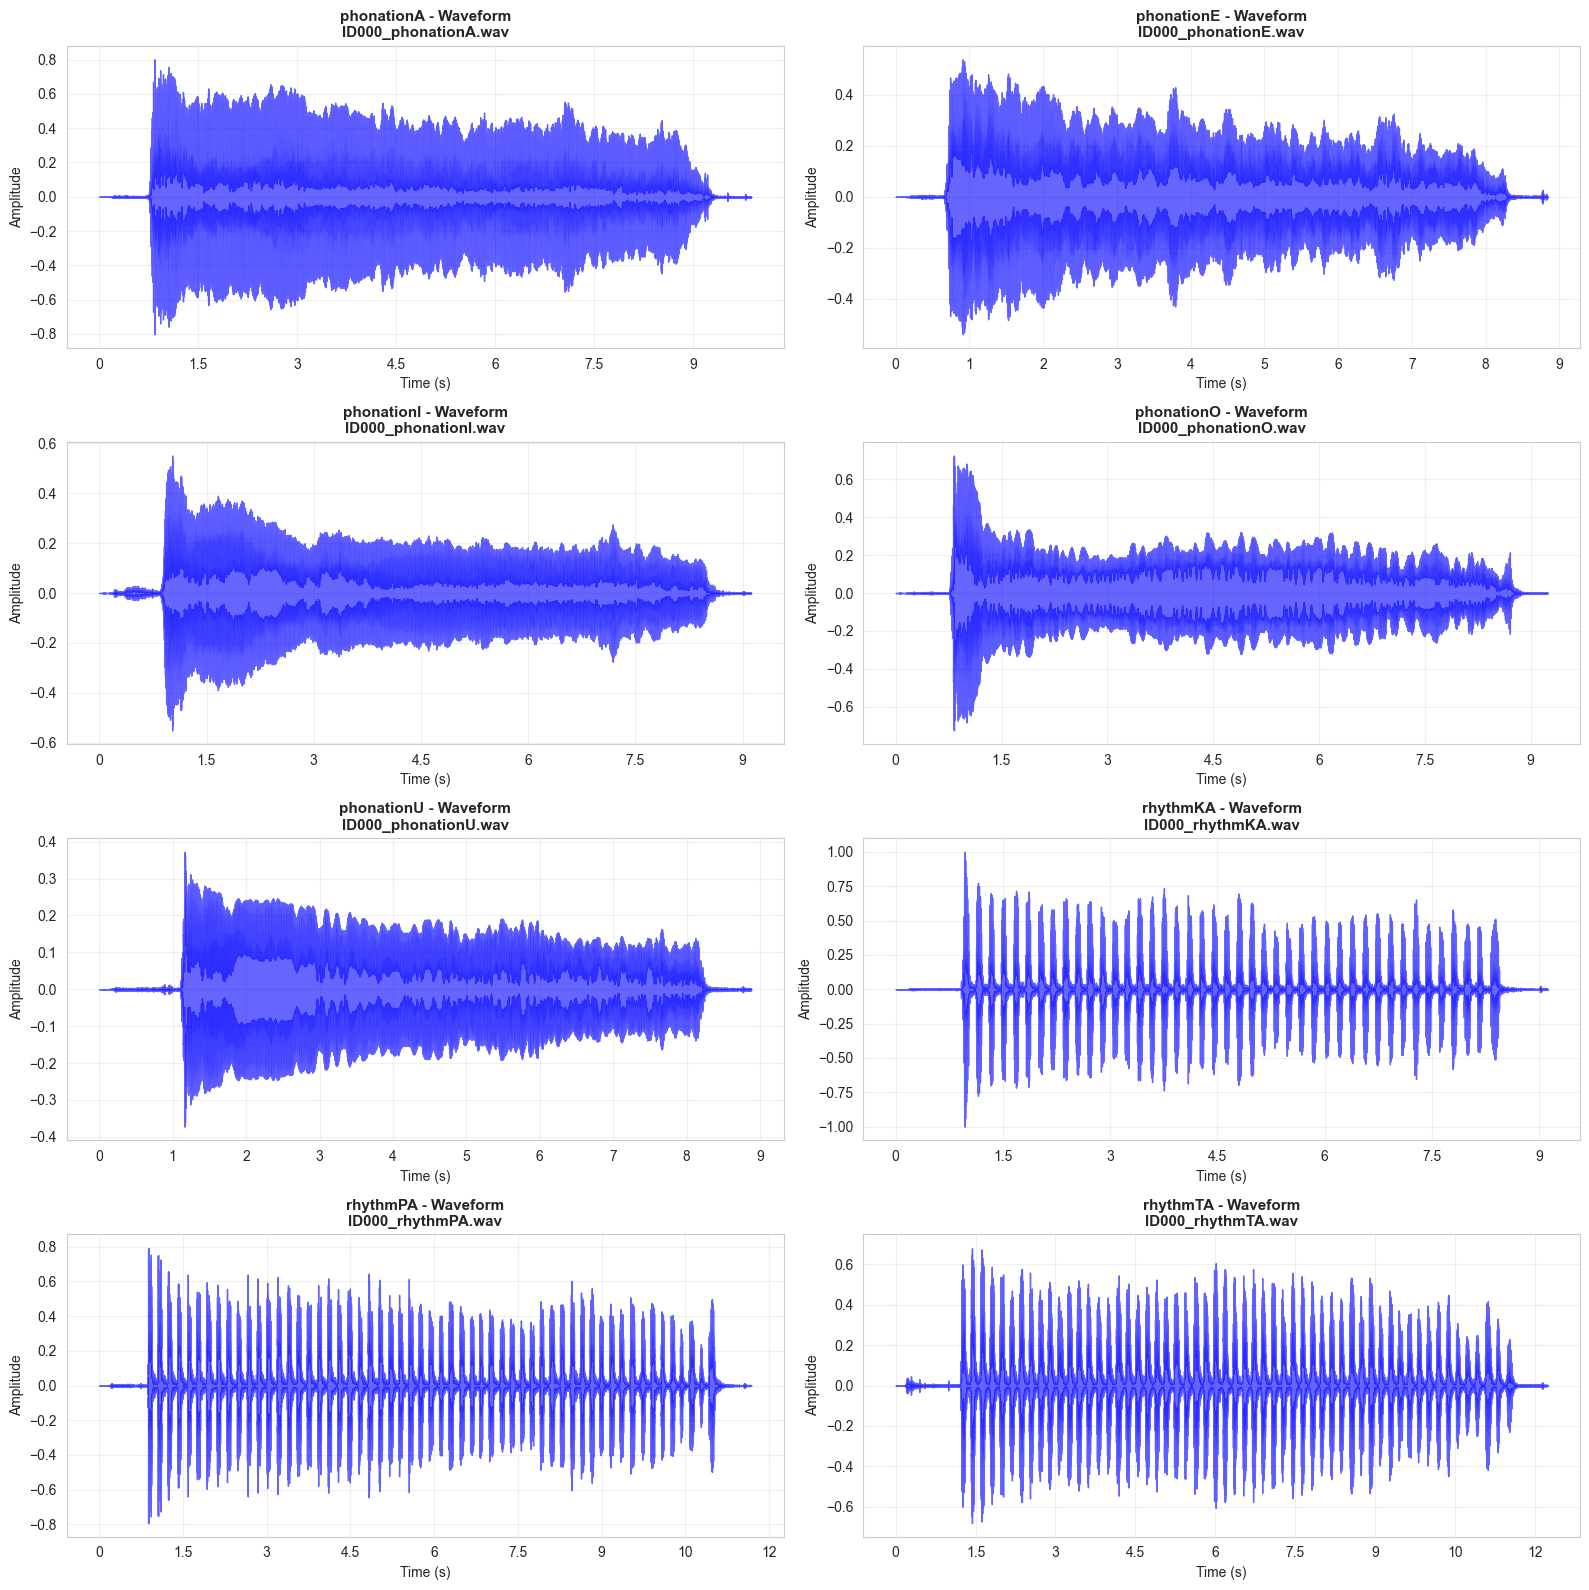

In [ ]:
# Visualize waveforms for sample files from each category
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.ravel()

for idx, category in enumerate(categories):
    category_path = os.path.join(base_path, category)
    if os.path.exists(category_path):
        files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
        
        if files:
            # Load first file
            file_path = os.path.join(category_path, files[0])
            y, sr = librosa.load(file_path, sr=None)
            
            # Plot waveform
            librosa.display.waveshow(y, sr=sr, ax=axes[idx], color='blue', alpha=0.6)
            axes[idx].set_title(f'{category} - Waveform\n{files[0]}', fontsize=11, fontweight='bold')
            axes[idx].set_xlabel('Time (s)', fontsize=10)
            axes[idx].set_ylabel('Amplitude', fontsize=10)
            axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
pdf_pages.savefig(fig, bbox_inches='tight', dpi=300)
plt.show()

---
## PART 3: Frequency Analysis (Spectrograms, Mel Spectrograms, MFCCs)
**By Azka Hafeez**

---


## 5. Spectrogram Analysis

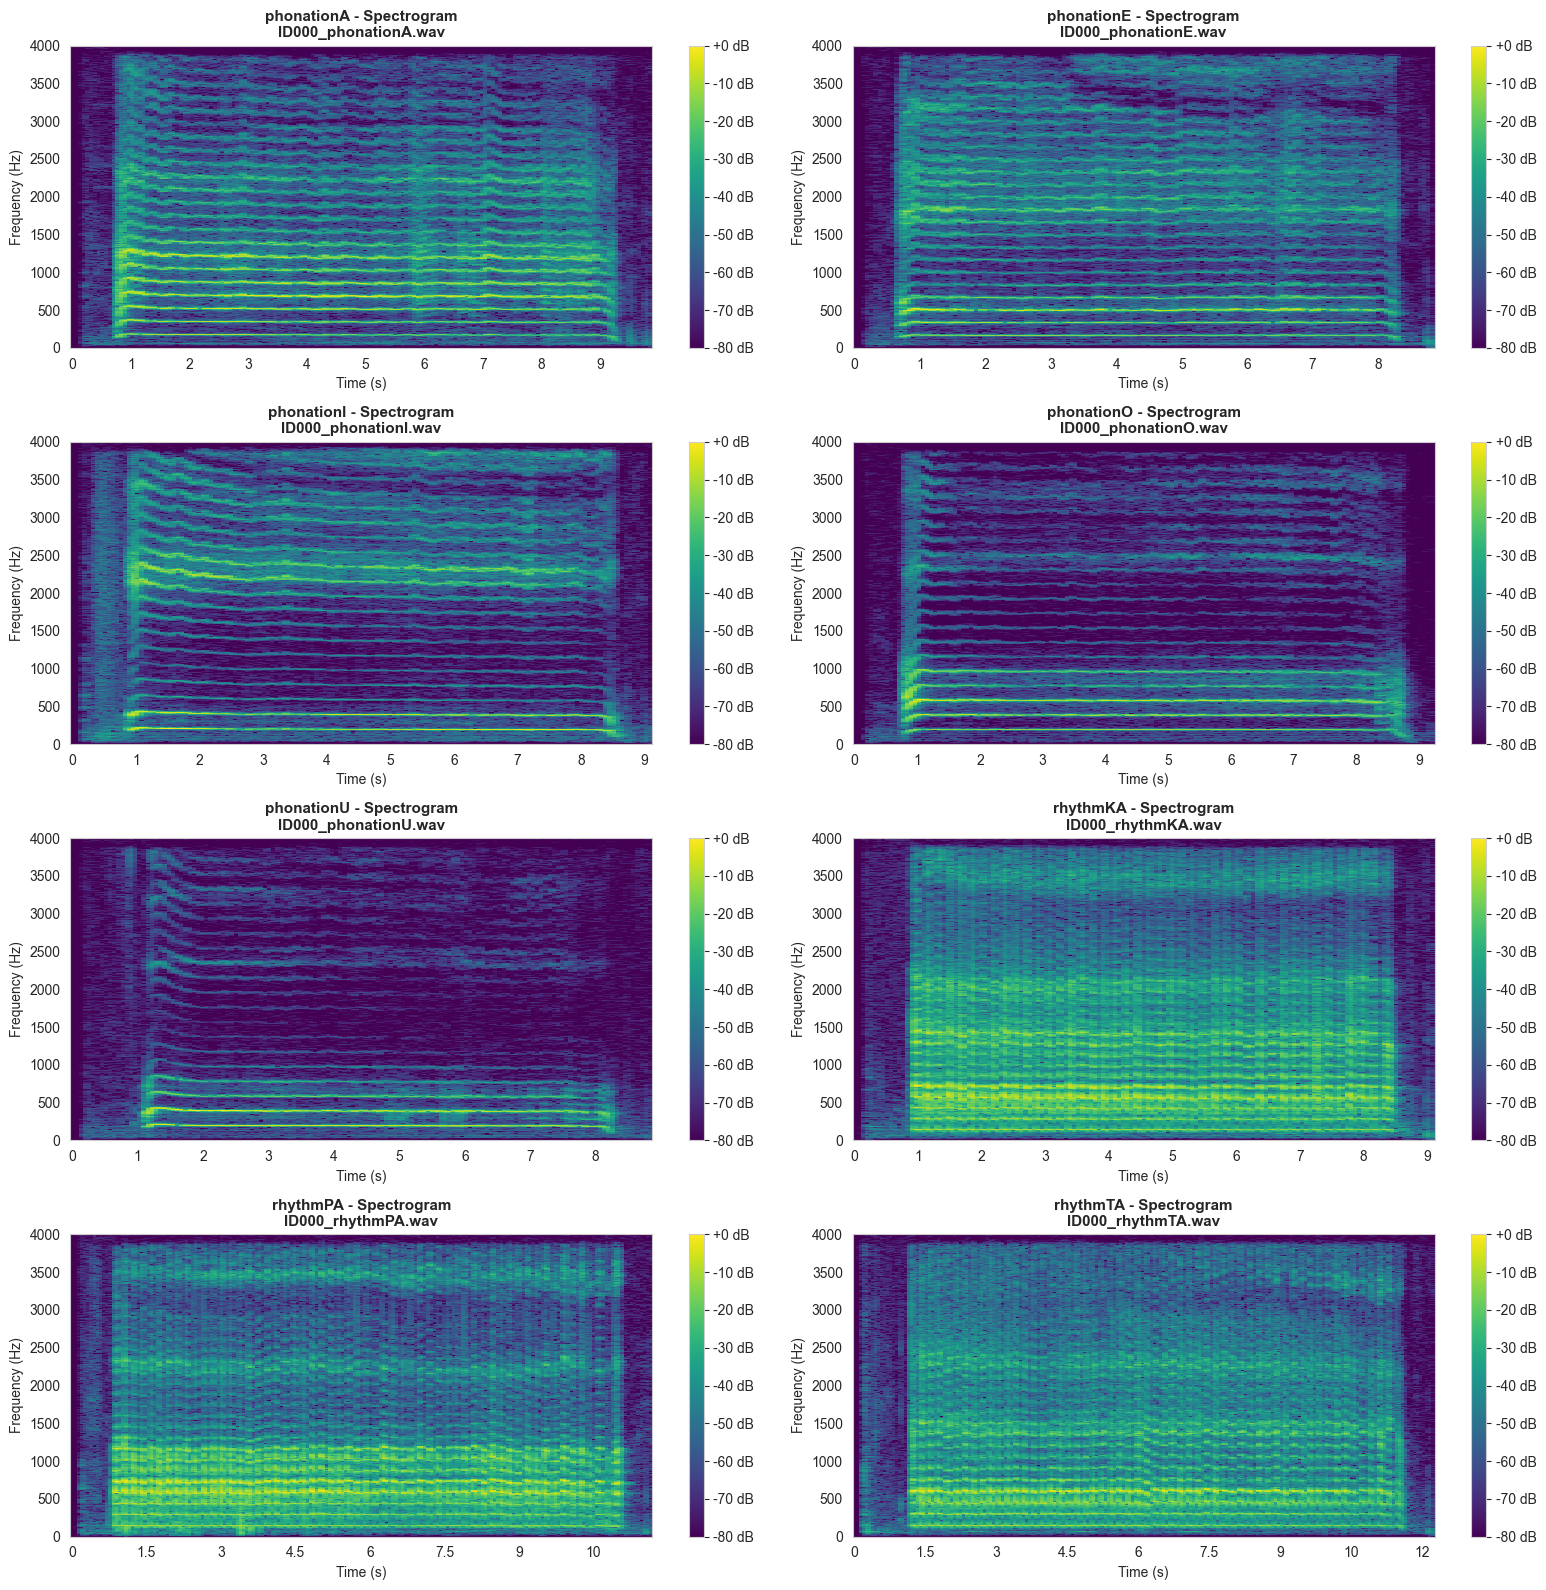

In [35]:
# Visualize spectrograms for sample files from each category
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.ravel()

for idx, category in enumerate(categories):
    category_path = os.path.join(base_path, category)
    if os.path.exists(category_path):
        files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
        
        if files:
            # Load first file
            file_path = os.path.join(category_path, files[0])
            y, sr = librosa.load(file_path, sr=None)
            
            # Compute spectrogram
            D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
            
            # Plot spectrogram
            img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[idx], cmap='viridis')
            axes[idx].set_title(f'{category} - Spectrogram\n{files[0]}', fontsize=11, fontweight='bold')
            axes[idx].set_xlabel('Time (s)', fontsize=10)
            axes[idx].set_ylabel('Frequency (Hz)', fontsize=10)
            fig.colorbar(img, ax=axes[idx], format='%+2.0f dB')

plt.tight_layout()
pdf_pages.savefig(fig, bbox_inches='tight', dpi=300)
plt.show()

## 6. Mel Spectrogram Analysis

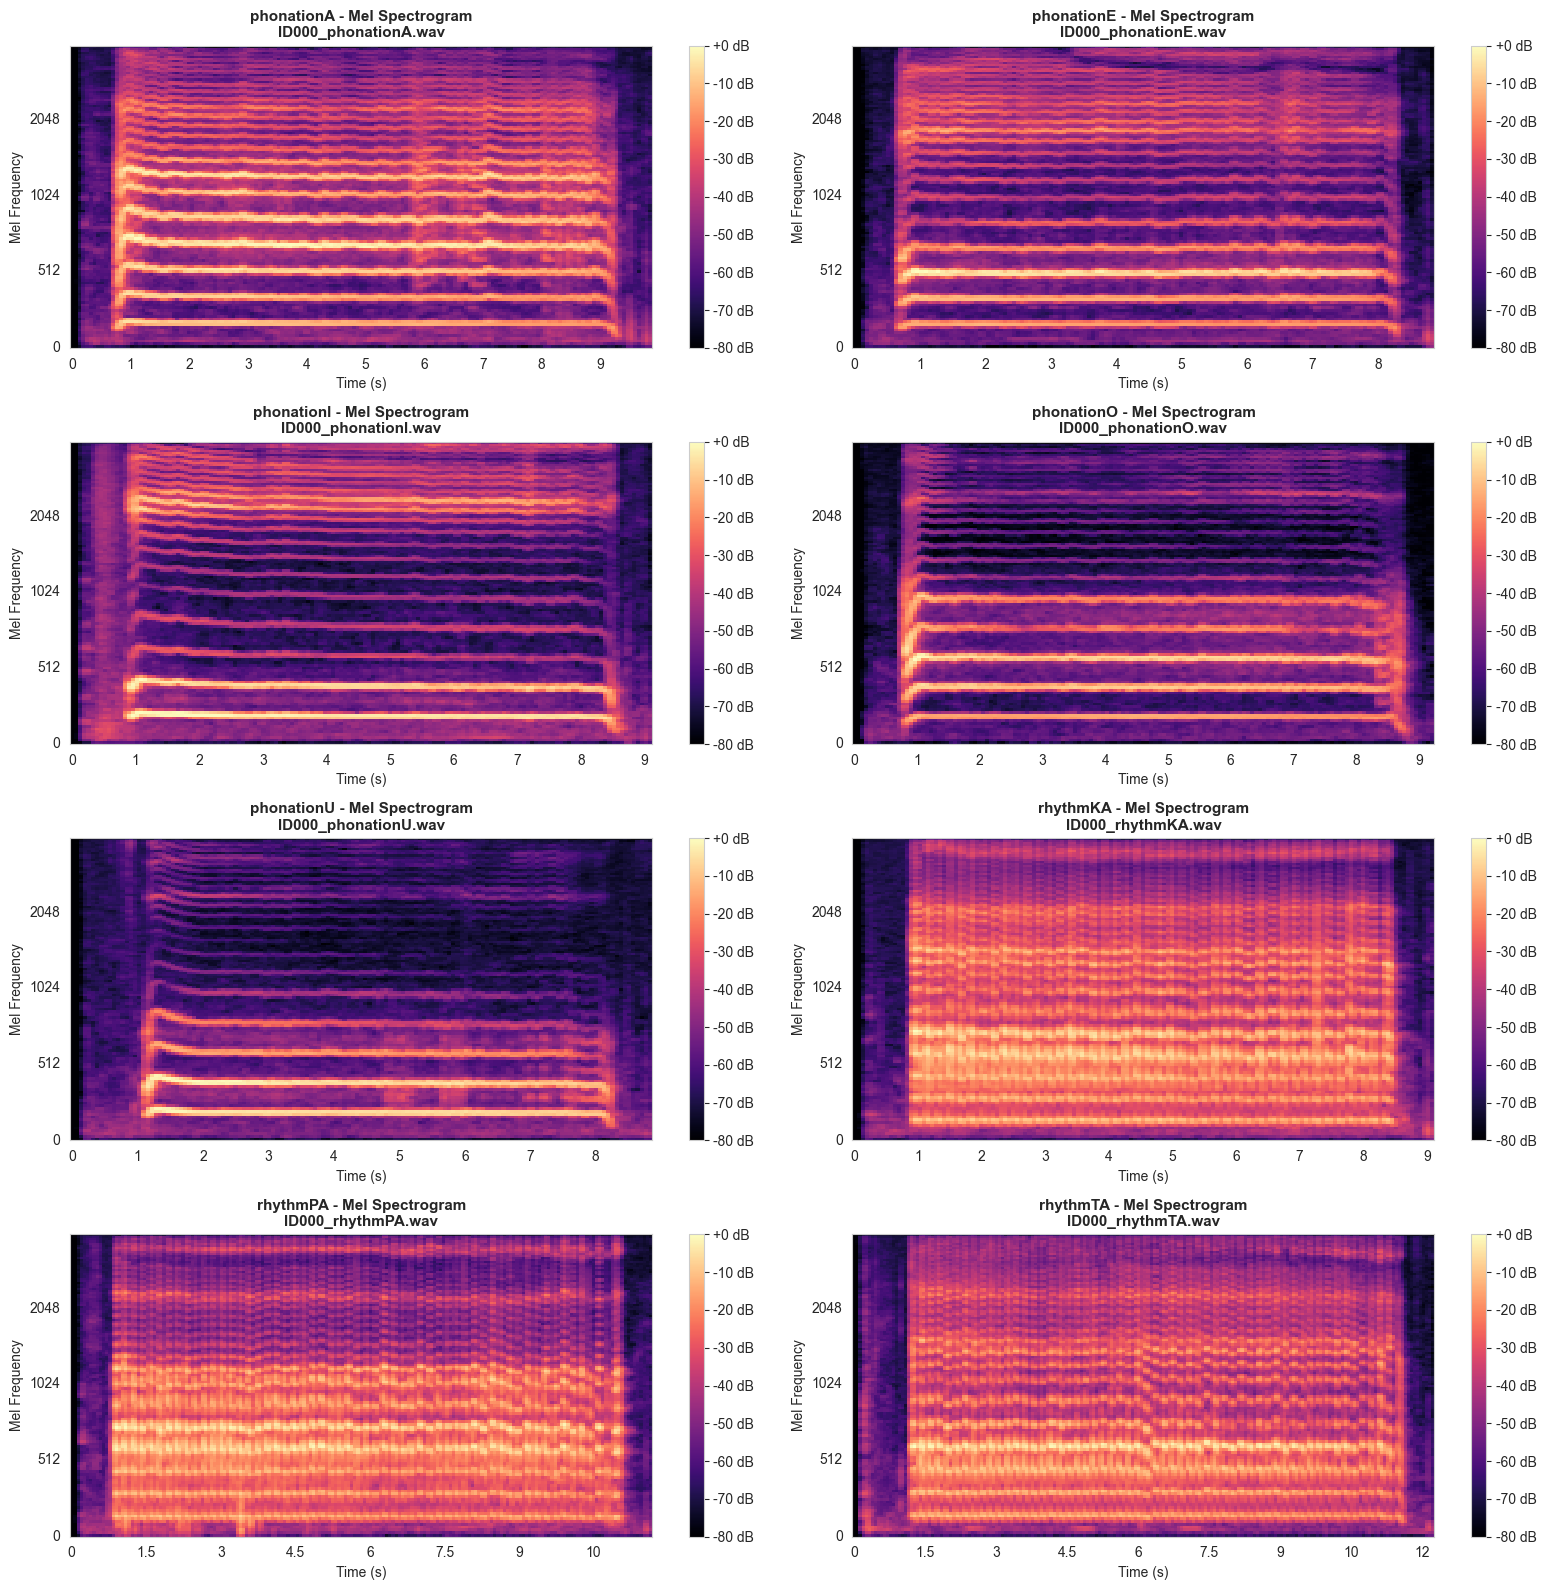

In [36]:
# Visualize mel spectrograms for sample files from each category
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.ravel()

for idx, category in enumerate(categories):
    category_path = os.path.join(base_path, category)
    if os.path.exists(category_path):
        files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
        
        if files:
            # Load first file
            file_path = os.path.join(category_path, files[0])
            y, sr = librosa.load(file_path, sr=None)
            
            # Compute mel spectrogram
            mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            
            # Plot mel spectrogram
            img = librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', 
                                          ax=axes[idx], cmap='magma')
            axes[idx].set_title(f'{category} - Mel Spectrogram\n{files[0]}', fontsize=11, fontweight='bold')
            axes[idx].set_xlabel('Time (s)', fontsize=10)
            axes[idx].set_ylabel('Mel Frequency', fontsize=10)
            fig.colorbar(img, ax=axes[idx], format='%+2.0f dB')

plt.tight_layout()
pdf_pages.savefig(fig, bbox_inches='tight', dpi=300)
plt.show()

## 7. MFCC Analysis

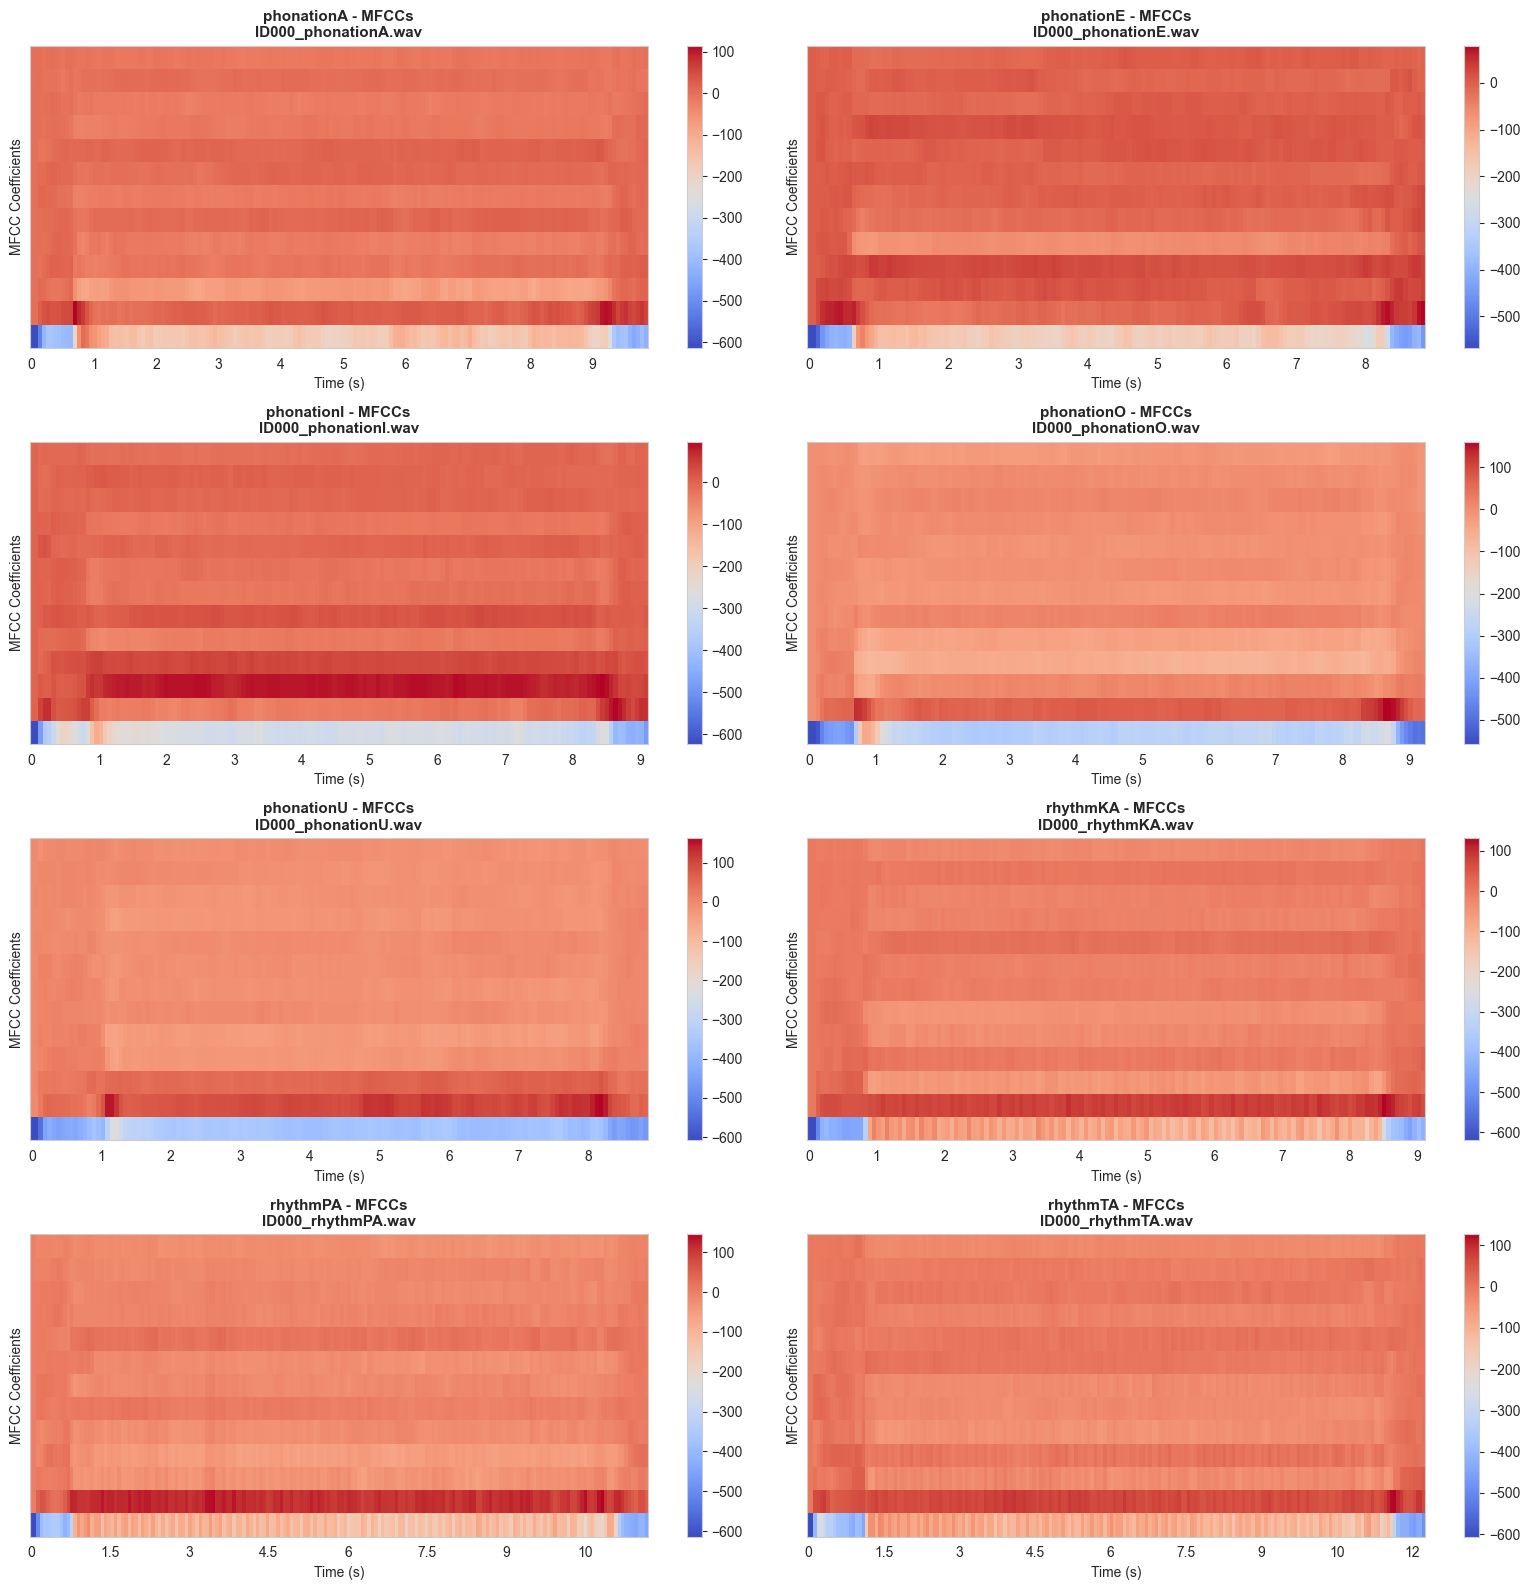

In [37]:
# Visualize MFCC features for sample files from each category
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.ravel()

for idx, category in enumerate(categories):
    category_path = os.path.join(base_path, category)
    if os.path.exists(category_path):
        files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
        
        if files:
            # Load first file
            file_path = os.path.join(category_path, files[0])
            y, sr = librosa.load(file_path, sr=None)
            
            # Compute MFCCs
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
            
            # Plot MFCC
            img = librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=axes[idx], cmap='coolwarm')
            axes[idx].set_title(f'{category} - MFCCs\n{files[0]}', fontsize=11, fontweight='bold')
            axes[idx].set_xlabel('Time (s)', fontsize=10)
            axes[idx].set_ylabel('MFCC Coefficients', fontsize=10)
            fig.colorbar(img, ax=axes[idx])

plt.tight_layout()
pdf_pages.savefig(fig, bbox_inches='tight', dpi=300)
plt.show()

---
## FINAL SECTION: Summary and Key Findings
**Compiled by: All Team Members**

---

## 8. Summary and Key Findings

In [38]:
# Create comprehensive summary
print("=" * 80)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 80)

print("\n1. DATASET COMPOSITION (Saneha Akhtar):")
print("-" * 80)
print(f"   Total Categories: {len(categories)}")
print(f"   - Phonation Categories: 5 (A, E, I, O, U)")
print(f"   - Rhythm Categories: 3 (KA, PA, TA)")
print(f"   Total Audio Files: {sum(file_counts.values())}")
print(f"\n   Files per Category:")
for category, count in file_counts.items():
    print(f"   - {category}: {count} files")
print("\n   Key Findings:")
print("   - Dataset is perfectly balanced with equal files per category")
print("   - Clear separation between phonation and rhythm categories")

print("\n2. AUDIO PROPERTIES & DURATION (Sohaib Mubashir):")
print("-" * 80)
if len(audio_df) > 0:
    print(f"   Average Duration: {audio_df['Duration (s)'].mean():.2f} ± {audio_df['Duration (s)'].std():.2f} seconds")
    print(f"   Duration Range: [{audio_df['Duration (s)'].min():.2f}, {audio_df['Duration (s)'].max():.2f}] seconds")
    print(f"   Sample Rate(s): {', '.join(map(str, audio_df['Sample Rate (Hz)'].unique()))} Hz")
print("\n   Key Findings:")
print("   - Consistent sample rate across all recordings (8kHz)")
print("   - Duration varies significantly - normalization recommended")
print("   - Waveform patterns differ between phonation and rhythm types")

print("\n3. FREQUENCY ANALYSIS (Azka Hafeez):")
print("-" * 80)
print("   Visualizations Generated:")
print("   - Spectrograms: Show frequency content over time")
print("   - Mel Spectrograms: Perceptual frequency scale analysis")
print("   - MFCCs: 13 coefficients capturing speech characteristics")
print("\n   Key Findings:")
print("   - Distinct spectral patterns between vowel phonations")
print("   - Rhythm categories show periodic patterns in spectrograms")
print("   - MFCCs effectively capture phonetic differences")

print("\n4. RECOMMENDATIONS FOR MODELING (Team Consensus):")
print("-" * 80)
print("   - Use MFCCs and mel spectrograms as primary features")
print("   - Apply data augmentation (time stretching, pitch shifting)")
print("   - Consider CNN architecture for spectrogram-based classification")
print("   - Implement duration normalization preprocessing")
print("   - Stratified k-fold cross-validation recommended")

print("\n" + "=" * 80)
print("EDA COMPLETE - TEAM CONTRIBUTIONS:")
print("Saneha Akhtar: Dataset Overview & Distribution Analysis")
print("Sohaib Mubashir: Audio Properties & Duration Analysis")
print("Azka Hafeez: Frequency & Spectral Analysis")
print("=" * 80)

EXPLORATORY DATA ANALYSIS SUMMARY

1. DATASET COMPOSITION (Saneha Akhtar):
--------------------------------------------------------------------------------
   Total Categories: 8
   - Phonation Categories: 5 (A, E, I, O, U)
   - Rhythm Categories: 3 (KA, PA, TA)
   Total Audio Files: 2176

   Files per Category:
   - phonationA: 272 files
   - phonationE: 272 files
   - phonationI: 272 files
   - phonationO: 272 files
   - phonationU: 272 files
   - rhythmKA: 272 files
   - rhythmPA: 272 files
   - rhythmTA: 272 files

   Key Findings:
   - Dataset is perfectly balanced with equal files per category
   - Clear separation between phonation and rhythm categories

2. AUDIO PROPERTIES & DURATION (Sohaib Mubashir):
--------------------------------------------------------------------------------
   Average Duration: 17.24 ± 10.08 seconds
   Duration Range: [5.40, 45.04] seconds
   Sample Rate(s): 8000 Hz

   Key Findings:
   - Consistent sample rate across all recordings (8kHz)
   - Duration

## 9. Save Plots

In [39]:
# Close PDF and save all plots
pdf_pages.close()

print(f"All plots saved to: {pdf_path}")

All plots saved to: plots\eda_analysis.pdf
